<a href="https://colab.research.google.com/github/krishnatatte884/CEIAssignments/blob/main/Satellite_LandUse_Change_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Satellite Land-Use Classifier & Temporal Change Detector
**Google Colab master notebook**

Run with **Runtime → Change runtime type → GPU**.  
This notebook implements the required 3-epoch frozen-head phase and 5-epoch partial fine-tuning phase, EuroSAT evaluation, 512-D embeddings, simulated change detection, ROC threshold selection, and five heatmaps.

In [1]:
!nvidia-smi
!pip -q install torch torchvision scikit-learn matplotlib tqdm streamlit

Fri Aug  7 10:41:21 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   34C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
!unzip -q -o /content/satellite-landuse-change-detector.zip -d /content/

In [4]:
!ls /content/satellite-landuse-change-detector

app.py	config.py  models  notebooks  outputs  README.md  requirements.txt  src


In [5]:
%cd /content/satellite-landuse-change-detector
!pip install -q -r requirements.txt

/content/satellite-landuse-change-detector


## 1. Clone/upload project and imports
If you uploaded the project folder to Colab, set `PROJECT` to that path.

In [6]:
from pathlib import Path
import sys, json, random, numpy as np, torch, matplotlib.pyplot as plt

PROJECT = Path('/content/satellite-landuse-change-detector')
if not PROJECT.exists():
    raise FileNotFoundError("Upload/clone the project to /content/satellite-landuse-change-detector")
sys.path.insert(0, str(PROJECT))

from config import *
from src.dataset import seed_everything, eurosat_loaders
from src.model import build_model, freeze_backbone, unfreeze_last_two_blocks, ResNet18FeatureExtractor
from src.train import fit
from src.evaluate import predict, classification_metrics, save_confusion_matrix, save_training_curves
from src.embeddings import extract_embeddings
from src.change_detection import make_simulated_pairs, select_threshold_youden, evaluate_threshold, save_roc
from src.heatmap import feature_difference_heatmap

seed_everything(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
MODEL_DIR.mkdir(exist_ok=True); OUTPUT_DIR.mkdir(exist_ok=True)
print(DEVICE)

cuda


## 2. EuroSAT stratified 80/20 split

In [7]:
train_loader, val_loader, classes, train_idx, val_idx = eurosat_loaders(
    root='/content/data', batch_size=BATCH_SIZE, image_size=IMAGE_SIZE,
    val_size=0.2, seed=SEED, num_workers=NUM_WORKERS
)
print(classes)
print(len(train_loader.dataset), len(val_loader.dataset))

100%|██████████| 94.3M/94.3M [00:01<00:00, 78.2MB/s]


['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
21600 5400


## 3. Phase 1 — frozen backbone, 3 epochs

In [8]:
import torch.nn as nn
model = build_model(num_classes=len(classes), pretrained=True).to(DEVICE)
freeze_backbone(model)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=HEAD_LR)

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
model, history = fit(
    model, train_loader, val_loader, criterion, optimizer,
    HEAD_EPOCHS, DEVICE, history=history,
    checkpoint_path=MODEL_DIR/'phase1_best.pt'
)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 187MB/s]


  0%|          | 0/338 [00:00<?, ?it/s]

  0%|          | 0/85 [00:00<?, ?it/s]

Epoch 1/3 | train loss 0.8947 acc 0.7203 | val loss 0.5717 acc 0.8285


...

  0%|          | 0/85 [00:00<?, ?it/s]

Epoch 2/3 | train loss 0.5580 acc 0.8181 | val loss 0.4669 acc 0.8520


  0%|          | 0/338 [00:00<?, ?it/s]

  0%|          | 0/85 [00:00<?, ?it/s]

Epoch 3/3 | train loss 0.4976 acc 0.8326 | val loss 0.4768 acc 0.8474


## 4. Phase 2 — unfreeze last two residual blocks, LR ÷ 10, 5 epochs

In [9]:
unfreeze_last_two_blocks(model)
optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=FINETUNE_LR)
model, history = fit(
    model, train_loader, val_loader, criterion, optimizer,
    FINETUNE_EPOCHS, DEVICE, history=history,
    checkpoint_path=MODEL_DIR/'best_resnet18.pt'
)
torch.save(model.state_dict(), MODEL_DIR/'best_resnet18.pt')
save_training_curves(history, OUTPUT_DIR/'training_curves.png')

  0%|          | 0/338 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7ee360ddd4e0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
         Exception ignored in:  <function _MultiProcessingDataLoaderIter.__del__ at 0x7ee360ddd4e0>
 Traceback (most recent call last):
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
^    ^^self._shutdown_workers()^
^^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
^    ^if w.is_alive():^
^  ^ ^ ^ ^^ ^ ^^^^^^^^

  0%|          | 0/85 [00:00<?, ?it/s]

Epoch 1/5 | train loss 0.2138 acc 0.9295 | val loss 0.1215 acc 0.9602


  0%|          | 0/338 [00:00<?, ?it/s]

...

Epoch 4/5 | train loss 0.0848 acc 0.9709 | val loss 0.0835 acc 0.9719


  0%|          | 0/338 [00:00<?, ?it/s]

  0%|          | 0/85 [00:00<?, ?it/s]

Epoch 5/5 | train loss 0.0765 acc 0.9741 | val loss 0.0733 acc 0.9730


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7ee360ddd4e0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1673, in _shutdown_workers
    w.join(timeout=_utils.MP_STATUS_CHECK_INTERVAL)
  File "/usr/lib/python3.12/multiprocessing/process.py", line 149, in join
    res = self._popen.wait(timeout)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/popen_fork.py", line 40, in wait
    if not wait([self.sentinel], timeout):
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/connection.py", line 1136, in wait
    ready = selector.select(timeout)
            ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/selectors.py", line 415, in select
    fd_event_list = self._selector.poll(timeout)
    

## 5. EuroSAT validation metrics

In [10]:
y_true, y_pred, probs = predict(model, val_loader, DEVICE)
report = classification_metrics(y_true, y_pred, classes, OUTPUT_DIR/'eurosat_metrics.json')
save_confusion_matrix(y_true, y_pred, classes, OUTPUT_DIR/'eurosat_confusion_matrix.png',
                      'EuroSAT Validation Confusion Matrix')
print('Macro-F1:', report['macro avg']['f1-score'])
for c in classes:
    print(c, 'F1=', round(report[c]['f1-score'], 4))

Macro-F1: 0.972417851618161
AnnualCrop F1= 0.9674
Forest F1= 0.9933
HerbaceousVegetation F1= 0.9575
Highway F1= 0.9721
Industrial F1= 0.9765
Pasture F1= 0.9718
PermanentCrop F1= 0.9365
Residential F1= 0.986
River F1= 0.9733
SeaLake F1= 0.9899


## 6. 512-D embeddings
ResNet18's global-average-pooled `layer4` output is 512-dimensional. The classifier head is not used here.

In [11]:
extractor = ResNet18FeatureExtractor(model).to(DEVICE)
embeddings, labels = extract_embeddings(extractor, val_loader, DEVICE)
print(embeddings.shape)
assert embeddings.shape[1] == 512

(5400, 512)


## 7. Simulated temporal pairs
**Important:** EuroSAT does not contain verified before/after images of the same geographic locations. This experiment is a reproducible proxy:
- same-class pair → unchanged (`0`)
- different-class pair → changed (`1`)

State this limitation explicitly in the report.

In [12]:
pairs, y_change, similarities = make_simulated_pairs(
    embeddings, labels, n_pairs=5000, changed_fraction=0.5, seed=SEED
)
threshold, auc, fpr, tpr, roc_thresholds = select_threshold_youden(y_change, similarities)
change_metrics = evaluate_threshold(y_change, similarities, threshold)
save_roc(fpr, tpr, auc, OUTPUT_DIR/'roc_curve.png')
print('ROC-AUC:', auc)
print('Selected cosine threshold:', threshold)
print(change_metrics)

ROC-AUC: 0.988088
Selected cosine threshold: 0.6067532896995544
{'accuracy': 0.9472, 'precision': 0.9497184231697506, 'recall': 0.9444, 'f1': 0.9470517448856799}


## 8. Save dashboard metadata

In [13]:
metadata = {
    'classes': classes,
    'similarity_threshold': threshold,
    'roc_auc': auc,
    'change_metrics': change_metrics,
    'seed': SEED,
    'change_protocol': 'simulated same-class unchanged / different-class changed'
}
with open(MODEL_DIR/'metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)
print(metadata)

{'classes': ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake'], 'similarity_threshold': 0.6067532896995544, 'roc_auc': 0.988088, 'change_metrics': {'accuracy': 0.9472, 'precision': 0.9497184231697506, 'recall': 0.9444, 'f1': 0.9470517448856799}, 'seed': 42, 'change_protocol': 'simulated same-class unchanged / different-class changed'}


## 9. Generate at least five feature-difference heatmaps

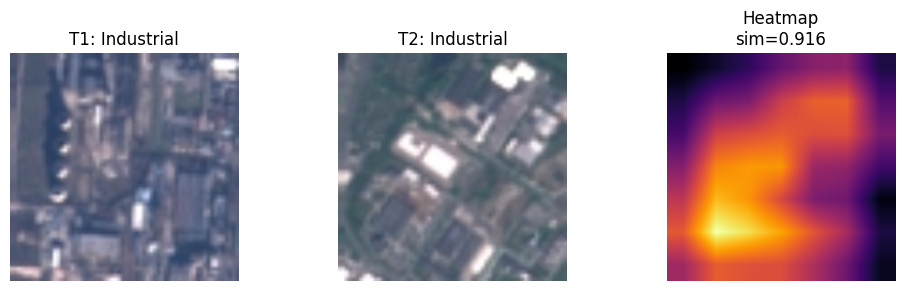

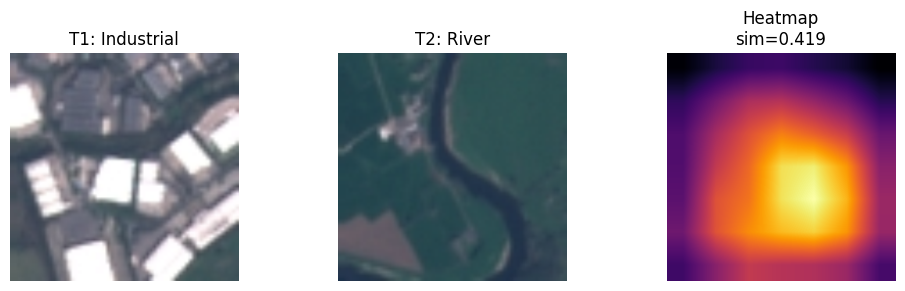

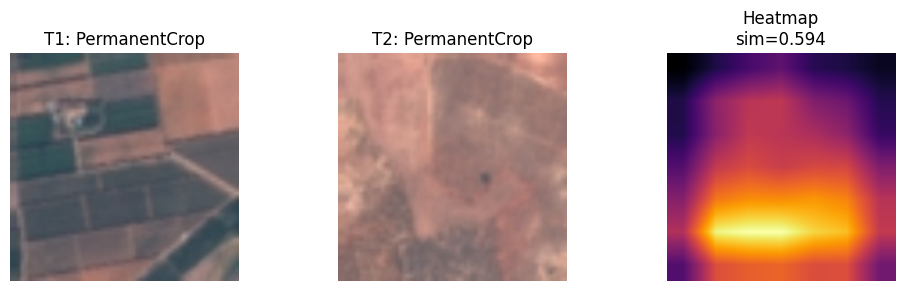

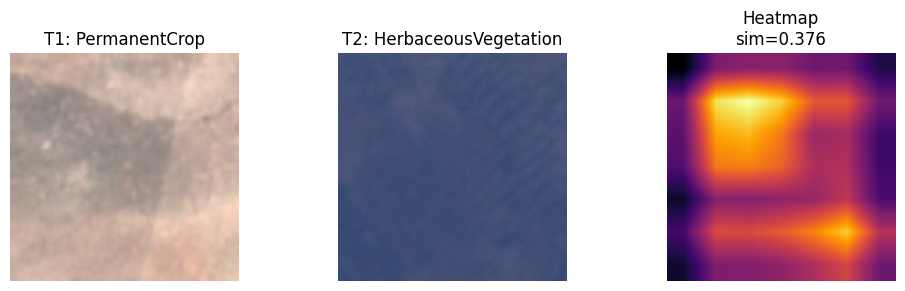

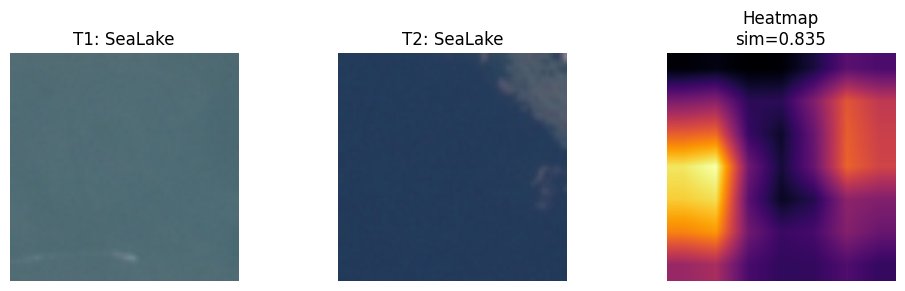

In [14]:
from torch.utils.data import DataLoader
from src.dataset import get_transforms

# val_loader.dataset is a Subset; access its transformed dataset by index.
sample_ds = val_loader.dataset
rng = np.random.default_rng(SEED)
chosen = rng.choice(len(pairs), size=5, replace=False)

heat_dir = OUTPUT_DIR/'heatmaps'
heat_dir.mkdir(exist_ok=True)

for n, pidx in enumerate(chosen, 1):
    i, j = pairs[pidx]
    img1, lab1 = sample_ds[int(i)]
    img2, lab2 = sample_ds[int(j)]
    x1, x2 = img1.unsqueeze(0).to(DEVICE), img2.unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        e1, f1 = extractor(x1)
        e2, f2 = extractor(x2)
    heat = feature_difference_heatmap(f1.cpu(), f2.cpu(), (224,224))
    sim = torch.nn.functional.cosine_similarity(e1, e2).item()

    # denormalize for display
    mean = torch.tensor([0.485,0.456,0.406])[:,None,None]
    std = torch.tensor([0.229,0.224,0.225])[:,None,None]
    a = (img1.cpu()*std+mean).clamp(0,1).permute(1,2,0).numpy()
    b = (img2.cpu()*std+mean).clamp(0,1).permute(1,2,0).numpy()

    fig, ax = plt.subplots(1,3,figsize=(10,3))
    ax[0].imshow(a); ax[0].set_title(f'T1: {classes[lab1]}')
    ax[1].imshow(b); ax[1].set_title(f'T2: {classes[lab2]}')
    ax[2].imshow(heat, cmap='inferno'); ax[2].set_title(f'Heatmap\nsim={sim:.3f}')
    for q in ax: q.axis('off')
    fig.tight_layout()
    fig.savefig(heat_dir/f'pair_{n}.png', dpi=200)
    plt.show()

## 10. UC Merced external holdout
The assignment requires UC Merced per-class F1, macro-F1 and a confusion matrix.

UC Merced has **21 classes**, while EuroSAT has **10**, so a direct label-for-label evaluation is invalid. Download UC Merced separately, create a documented semantic mapping for only defensible overlapping categories, and never use those samples for training.

Suggested conservative mappings to review manually:
- `forest` → `Forest`
- `river` → `River`
- `residential` subclasses → `Residential`
- `freeway` → `Highway`

Do not map ambiguous classes merely to increase sample count. After arranging mapped images into folders named exactly as the target EuroSAT classes, use the template below.

In [ ]:
# Example after you create /content/ucmerced_mapped/<EuroSATClass>/*.tif:
#
# from src.dataset import imagefolder_loader
# uc_loader, uc_ds = imagefolder_loader('/content/ucmerced_mapped', batch_size=64)
#
# IMPORTANT: ImageFolder label indices follow folder alphabetical order, not EuroSAT's model indices.
# Remap UC targets to EuroSAT indices before computing metrics, or create a custom mapped Dataset.
#
# Then generate:
# - outputs/ucmerced_metrics.json
# - outputs/ucmerced_confusion_matrix.png
#
# Keep UC Merced completely outside training/model-selection.

## 11. Final files to download

In [15]:
print('Checkpoint:', MODEL_DIR/'best_resnet18.pt')
print('Metadata:', MODEL_DIR/'metadata.json')
print('Outputs:')
for p in sorted(OUTPUT_DIR.rglob('*')):
    if p.is_file(): print(' -', p)

Checkpoint: /content/satellite-landuse-change-detector/models/best_resnet18.pt
Metadata: /content/satellite-landuse-change-detector/models/metadata.json
Outputs:
 - /content/satellite-landuse-change-detector/outputs/eurosat_confusion_matrix.png
 - /content/satellite-landuse-change-detector/outputs/eurosat_metrics.json
 - /content/satellite-landuse-change-detector/outputs/heatmaps/pair_1.png
 - /content/satellite-landuse-change-detector/outputs/heatmaps/pair_2.png
 - /content/satellite-landuse-change-detector/outputs/heatmaps/pair_3.png
 - /content/satellite-landuse-change-detector/outputs/heatmaps/pair_4.png
 - /content/satellite-landuse-change-detector/outputs/heatmaps/pair_5.png
 - /content/satellite-landuse-change-detector/outputs/roc_curve.png
 - /content/satellite-landuse-change-detector/outputs/training_curves.png


In [16]:
from pathlib import Path

PROJECT = Path("/content/satellite-landuse-change-detector")

for p in sorted((PROJECT / "outputs").rglob("*")):
    if p.is_file():
        print(p)

print("\nMODEL FILES:")
for p in sorted((PROJECT / "models").rglob("*")):
    if p.is_file():
        print(p)

/content/satellite-landuse-change-detector/outputs/eurosat_confusion_matrix.png
/content/satellite-landuse-change-detector/outputs/eurosat_metrics.json
/content/satellite-landuse-change-detector/outputs/heatmaps/pair_1.png
/content/satellite-landuse-change-detector/outputs/heatmaps/pair_2.png
/content/satellite-landuse-change-detector/outputs/heatmaps/pair_3.png
/content/satellite-landuse-change-detector/outputs/heatmaps/pair_4.png
/content/satellite-landuse-change-detector/outputs/heatmaps/pair_5.png
/content/satellite-landuse-change-detector/outputs/roc_curve.png
/content/satellite-landuse-change-detector/outputs/training_curves.png

MODEL FILES:
/content/satellite-landuse-change-detector/models/best_resnet18.pt
/content/satellite-landuse-change-detector/models/metadata.json
/content/satellite-landuse-change-detector/models/phase1_best.pt


In [17]:
import json

with open(PROJECT / "outputs/eurosat_metrics.json") as f:
    euro = json.load(f)

with open(PROJECT / "models/metadata.json") as f:
    meta = json.load(f)

print("===== EUROSAT RESULTS =====")
print("Accuracy:", euro["accuracy"])
print("Macro Precision:", euro["macro avg"]["precision"])
print("Macro Recall:", euro["macro avg"]["recall"])
print("Macro F1:", euro["macro avg"]["f1-score"])

print("\n===== PER-CLASS F1 =====")
for cls in meta["classes"]:
    print(f"{cls:25s}: {euro[cls]['f1-score']:.4f}")

print("\n===== CHANGE DETECTION =====")
print("ROC-AUC:", meta["roc_auc"])
print("Cosine threshold:", meta["similarity_threshold"])
print("Accuracy:", meta["change_metrics"]["accuracy"])
print("Precision:", meta["change_metrics"]["precision"])
print("Recall:", meta["change_metrics"]["recall"])
print("F1:", meta["change_metrics"]["f1"])

===== EUROSAT RESULTS =====
Accuracy: 0.9729629629629629
Macro Precision: 0.9720842966556423
Macro Recall: 0.9732000000000001
Macro F1: 0.972417851618161

===== PER-CLASS F1 =====
AnnualCrop               : 0.9674
Forest                   : 0.9933
HerbaceousVegetation     : 0.9575
Highway                  : 0.9721
Industrial               : 0.9765
Pasture                  : 0.9718
PermanentCrop            : 0.9365
Residential              : 0.9860
River                    : 0.9733
SeaLake                  : 0.9899

===== CHANGE DETECTION =====
ROC-AUC: 0.988088
Cosine threshold: 0.6067532896995544
Accuracy: 0.9472
Precision: 0.9497184231697506
Recall: 0.9444
F1: 0.9470517448856799


In [18]:
!cd /content && zip -r satellite_project_results.zip \
satellite-landuse-change-detector/models \
satellite-landuse-change-detector/outputs

  adding: satellite-landuse-change-detector/models/ (stored 0%)
  adding: satellite-landuse-change-detector/models/best_resnet18.pt (deflated 7%)
  adding: satellite-landuse-change-detector/models/phase1_best.pt (deflated 7%)
  adding: satellite-landuse-change-detector/models/metadata.json (deflated 41%)
  adding: satellite-landuse-change-detector/outputs/ (stored 0%)
  adding: satellite-landuse-change-detector/outputs/training_curves.png (deflated 14%)
  adding: satellite-landuse-change-detector/outputs/roc_curve.png (deflated 12%)
  adding: satellite-landuse-change-detector/outputs/eurosat_confusion_matrix.png (deflated 17%)
  adding: satellite-landuse-change-detector/outputs/heatmaps/ (stored 0%)
  adding: satellite-landuse-change-detector/outputs/heatmaps/pair_3.png (deflated 1%)
  adding: satellite-landuse-change-detector/outputs/heatmaps/pair_5.png (deflated 2%)
  adding: satellite-landuse-change-detector/outputs/heatmaps/pair_1.png (deflated 1%)
  adding: satellite-landuse-chang

In [19]:
from google.colab import files
files.download("/content/satellite_project_results.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>